# CAS recurring crash areas: modelling, leaderboard and recommendation

This notebook builds the feature matrix, trains the baselines and candidate models on a strict
temporal split, evaluates them with ranking metrics at a review capacity, and applies the spec
5.11 decision rule to recommend a model for deployment.

It reads the panel produced by `01_eda.ipynb` and does not repeat any exploratory analysis.

**What to take from this notebook.** The gradient-boosted model beats the strongest non-ML
baseline on both locked test years with bootstrap intervals that exclude zero, so an ML model is
recommended. Calibration matters more than ranking here: it cuts the Brier score by roughly two
thirds without changing the ordering. The binding limitation is eligible coverage, not model
quality.

## 1. Setup

In [1]:
import sys, json, time, warnings, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from cas_area import (io, grid, panel, features, metrics, modelling, evaluation,
                      GRID_VERSION, FEATURE_SCHEMA_VERSION, MODEL_VERSION, RANDOM_SEED)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["figure.dpi"] = 110
np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

FIGURES = ROOT / "outputs" / "figures"; FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUTS = ROOT / "outputs"
print(f"model {MODEL_VERSION} | grid {GRID_VERSION} | features {FEATURE_SCHEMA_VERSION}")

model cas-area-risk-1.0.0 | grid nztm-1km-origin0-v1 | features cas-area-features-1.0.0


In [2]:
manifest = json.loads((ROOT / "data" / "processed" / "snapshot_manifest.json").read_text())
SNAPSHOT_ID = io.snapshot_id(manifest)

panel_frame = pd.read_parquet(ROOT / "data" / "processed" / "panel_1km_lag0.parquet")
crashes = io.add_severity_flags(io.load_raw(io.raw_csv_path(ROOT)))
crashes = grid.assign_cells(crashes)
records = features.prepare_records(crashes)

print(f"snapshot {SNAPSHOT_ID} | panel rows {len(panel_frame):,} | crash records {len(records):,}")

snapshot 967a34b12525 | panel rows 309,052 | crash records 705,609


## 2. Feature engineering

Every feature for target year `t` is computed strictly from crash records in `t-5` to `t-1`,
over three windows: `t-1`, `t-3` to `t-1`, and `t-5` to `t-1`. Identifiers, raw coordinates and
anything from year `t` or later are never predictors (spec 5.7).

Missing values are handled explicitly rather than left to the model: counts and shares are zero
when a window holds no crashes, while medians and modal numerics take a sentinel plus a paired
`*_missing` indicator, so "no data" is distinguishable from a real low value.

In [3]:
feature_path = ROOT / "data" / "processed" / "features_1km_lag0.parquet"
if feature_path.exists():
    feature_matrix = pd.read_parquet(feature_path)
    print("loaded cached feature matrix")
else:
    t = time.time()
    feature_matrix = features.build_features(records, panel_frame)
    feature_matrix.to_parquet(feature_path, index=False)
    print(f"built feature matrix in {time.time() - t:.0f}s")

predictors = features.predictor_columns(feature_matrix)
predictors_no_geo = features.predictor_columns(feature_matrix, include_geography=False)
print(f"{feature_matrix.shape[0]:,} rows | {len(predictors)} predictors "
      f"| {len(predictors_no_geo)} without region and TLA")

built feature matrix in 47s
309,052 rows | 178 predictors | 176 without region and TLA


In [4]:
dictionary = features.feature_dictionary(feature_matrix)
dictionary.to_csv(OUTPUTS / "feature_dictionary.csv", index=False)
display(dictionary.groupby("group").size().rename("features").to_frame())
display(dictionary.head(12))

,features
group,
crash conditions,48
crash-frequency history,12
data quality,39
other,6
road context / geography,17
road users,36
severity history,20


,name,group,lookback_window,dtype,missing_rule
0,dark_count_1y,crash conditions,t-1,float64,zero-filled
1,dark_count_3y,crash conditions,t-3 to t-1,float64,zero-filled
2,dark_count_5y,crash conditions,t-5 to t-1,int64,zero-filled
3,dark_share_1y,crash conditions,t-1,float64,zero-filled
4,dark_share_3y,crash conditions,t-3 to t-1,float64,zero-filled
5,dark_share_5y,crash conditions,t-5 to t-1,float64,zero-filled
6,holiday_count_1y,crash conditions,t-1,float64,zero-filled
7,holiday_count_3y,crash conditions,t-3 to t-1,float64,zero-filled
8,holiday_count_5y,crash conditions,t-5 to t-1,int8,zero-filled
9,holiday_share_1y,crash conditions,t-1,float64,zero-filled


In [5]:
assert feature_matrix[predictors].isna().sum().sum() == 0, "predictors must be complete"
banned = {"cell_id", "X", "Y", "OBJECTID", "crashYear", "crashFinancialYear", "target"}
assert not banned & set(predictors)
assert "history_sufficiency" not in predictors
print("Feature matrix passes structural checks: no nulls, no identifiers, no target leakage.")

Feature matrix passes structural checks: no nulls, no identifiers, no target leakage.


### Leakage tests

These are the safeguard that makes the whole backtest meaningful. They assert that no feature
for target year `t` uses any crash from year `t` or later, that the target uses only year `t`,
and that shifting all target-year crashes out of the data leaves every feature unchanged.

In [6]:
result = subprocess.run([sys.executable, "-m", "pytest", "tests", "-q"],
                        cwd=ROOT, capture_output=True, text=True)
print(result.stdout[-2500:])
assert result.returncode == 0, "leakage or grid tests failed"


........................                                                 [100%]
24 passed in 2.79s



## 3. Temporal split

Fitting, encoding, imputation and calibration use training and validation years only. The 2024
and 2025 outcomes are never seen during fitting or calibration.

In [7]:
display(modelling.split_table())

train = feature_matrix[feature_matrix.target_year.isin(modelling.TRAIN_YEARS)]
train_val = feature_matrix[feature_matrix.target_year.isin(
    list(modelling.TRAIN_YEARS) + [modelling.VALIDATION_YEAR])]
years = {y: feature_matrix[feature_matrix.target_year == y] for y in (2023, 2024, 2025)}

print(f"train 2011-2022: {len(train):,} rows, prevalence {train.target.mean():.2%}")
for y, frame in years.items():
    print(f"{y}: {len(frame):,} rows, prevalence {frame.target.mean():.2%}, "
          f"positives {int(frame.target.sum()):,}")
print("\nExpanding-window tuning folds (train -> predict):")
for train_years, v in modelling.expanding_folds():
    print(f"  {train_years[0]}-{train_years[-1]} -> {v}")

,partition,target_years,feature_years,purpose
0,Training and tuning,2011-2022,prior five per target,Fit pipeline and hyperparameters
1,Validation,2023,2018-2022,Select model and shortlist policy
2,Locked test 1,2024,2019-2023,Primary future-year test
3,Locked test 2,2025,2020-2024,Temporal robustness test
4,Excluded,2026,n/a,Partial outcome year


train 2011-2022: 244,915 rows, prevalence 7.76%
2023: 21,558 rows, prevalence 7.76%, positives 1,672
2024: 21,396 rows, prevalence 7.77%, positives 1,662
2025: 21,183 rows, prevalence 7.95%, positives 1,684

Expanding-window tuning folds (train -> predict):
  2011-2018 -> 2019
  2011-2019 -> 2020
  2011-2020 -> 2021
  2011-2021 -> 2022
  2011-2022 -> 2023


## 4. Baselines

Implemented before any ML model, so there is a genuine bar to clear. The smoothed share uses
`alpha=1, beta=20`: `beta` is large relative to `alpha` so a single severe crash in a
low-volume cell cannot outrank a sustained pattern.

In [8]:
scores = {y: pd.DataFrame(index=frame.index) for y, frame in years.items()}
for name, fn in modelling.BASELINES.items():
    for y, frame in years.items():
        scores[y][name] = fn(frame)
print("Baselines scored:", ", ".join(modelling.BASELINES))

Baselines scored: baseline_random, baseline_recent_severe, baseline_smoothed_share


## 5. Candidate models

Weighted logistic regression, random forest and gradient-boosted trees, with class weighting
only and no SMOTE. Validation year 2023 is predicted from training years alone; the locked test
years are predicted from training plus validation.

A gradient-boosted variant trained **without** region and TLA checks whether the model is simply
memorising geography (spec 5.7).

### TuiML

TuiML was used to fit and cross-check the gradient-boosted and logistic candidates. Its runs,
parameters and model ids are recorded in `outputs/tuiml_run_log.md`.

The final models are fitted locally, and this is a reported limitation rather than a silent
fallback. `tuiml_predict` returns hard 0/1 class labels even with `return_proba: true`, so it
cannot produce the continuous probabilities this product needs: a capacity-limited review list
must rank every eligible cell, and there is no way to take a top 50 from binary labels. TuiML
also offers no year-aware splitter, no ranking-at-K metrics, and no way to load its saved
artefact outside its own environment. The cause was isolated rather than assumed; see the log.

In [9]:
print((ROOT / "outputs" / "tuiml_run_log.md").read_text()[:1800])

# TuiML usage log

Recorded so every TuiML call in the notebooks is reproducible, per the build
instruction to name the tool and parameters used and to report errors rather
than silently falling back to local training.

## Tools inspected

| Tool | Purpose | Outcome |
|---|---|---|
| `tuiml_list(category='algorithm', type='classifier')` | Find candidate models | 89 classifiers available, including `LogisticRegression`, `RandomForestClassifier`, `LightGBMClassifier`, `XGBoostClassifier`, `CatBoostClassifier` |
| `tuiml_list(category='splitting')` | Find a year-aware splitter | 14 splitters, none year-aware. `TimeSeriesSplit` splits on row order, not on a year column |
| `tuiml_describe('LightGBMClassifier')` | Check the parameter schema | No `class_weight` / `scale_pos_weight` parameter exposed |
| `tuiml_upload_data(file_path=..., name='cas_area_train_2011_2022')` | Register the training panel | Success: 244,915 rows, 169 numeric features |
| `tuiml_train(...)` | Fit the gradient-boost

In [10]:
specs = [
    ("logistic_regression", modelling.make_logistic, predictors),
    ("random_forest", modelling.make_random_forest, predictors),
    ("gradient_boosted", modelling.make_gradient_boosted, predictors),
    ("gradient_boosted_no_region", modelling.make_gradient_boosted, predictors_no_geo),
]

for name, factory, columns in specs:
    t = time.time()
    scores[2023][name] = modelling.fit_predict(factory, train, years[2023], columns)
    for y in (2024, 2025):
        scores[y][name] = modelling.fit_predict(factory, train_val, years[y], columns)
    print(f"{name:30s} fitted in {time.time() - t:5.0f}s")

logistic_regression            fitted in    20s


random_forest                  fitted in    49s


gradient_boosted               fitted in    15s


gradient_boosted_no_region     fitted in    14s


## 6. Calibration

The selected model type is calibrated with isotonic regression on pooled out-of-fold predictions
from the 2019 to 2023 expanding-window folds. No 2024 or 2025 outcome is ever used.

In [11]:
t = time.time()
oof = modelling.out_of_fold_predictions(modelling.make_gradient_boosted, feature_matrix, predictors)
calibrator = modelling.fit_calibrator(oof, method="isotonic")
for y in (2023, 2024, 2025):
    scores[y]["gradient_boosted_calibrated"] = modelling.apply_calibrator(
        calibrator, scores[y]["gradient_boosted"].to_numpy())
print(f"calibrated on {len(oof):,} pooled out-of-fold predictions in {time.time() - t:.0f}s")
print("fold years used:", sorted(oof.target_year.unique()))

calibrated on 107,813 pooled out-of-fold predictions in 22s
fold years used: [2019, 2020, 2021, 2022, 2023]


## 7. Evaluation

Ranking metrics at a review capacity are primary. Accuracy appears nowhere as a selection metric.

In [12]:
MODELS = list(modelling.BASELINES) + [s[0] for s in specs] + ["gradient_boosted_calibrated"]

rows = []
for y, frame in years.items():
    for model in MODELS:
        scored = frame.assign(score=scores[y][model].to_numpy())
        rows.append(evaluation.evaluate_model(scored, "score", model, y))
results = pd.DataFrame(rows)

for y in (2023, 2024, 2025):
    print(f"\n=== target year {y} ===")
    display(results[results.year == y]
            .sort_values("primary_within_region_recall_5pct", ascending=False)
            .drop(columns=["year"]).style.format({
                "primary_within_region_recall_5pct": "{:.4f}", "national_recall_5pct": "{:.4f}",
                "waikato_recall_50": "{:.4f}", "waikato_recall_50_ceiling": "{:.4f}",
                "pr_auc": "{:.4f}", "roc_auc": "{:.4f}", "brier": "{:.4f}"}))


=== target year 2023 ===


,model,primary_within_region_recall_5pct,national_recall_5pct,waikato_recall_50,waikato_recall_50_ceiling,pr_auc,roc_auc,brier
6,gradient_boosted_no_region,0.3011,0.3319,0.1132,0.1887,0.4124,0.8204,0.1528
5,gradient_boosted,0.2942,0.3313,0.1132,0.1887,0.4139,0.8209,0.1530
7,gradient_boosted_calibrated,0.2913,0.3313,0.1094,0.1887,0.4057,0.8216,0.0571
3,logistic_regression,0.2904,0.3373,0.1132,0.1887,0.4112,0.8188,0.1649
4,random_forest,0.2759,0.3301,0.1132,0.1887,0.4029,0.8078,0.0763
1,baseline_recent_severe,0.2331,0.2877,0.1132,0.1887,nan,nan,nan
2,baseline_smoothed_share,0.0818,0.0772,0.0264,0.1887,0.0775,0.4518,0.0726
0,baseline_random,0.0493,0.0574,0.0189,0.1887,0.0792,0.5029,0.3292



=== target year 2024 ===


,model,primary_within_region_recall_5pct,national_recall_5pct,waikato_recall_50,waikato_recall_50_ceiling,pr_auc,roc_auc,brier
13,gradient_boosted,0.2628,0.3177,0.1422,0.2155,0.3775,0.8017,0.1571
15,gradient_boosted_calibrated,0.2623,0.3171,0.1379,0.2155,0.3677,0.8012,0.0590
11,logistic_regression,0.2610,0.3171,0.1336,0.2155,0.3774,0.8012,0.1655
14,gradient_boosted_no_region,0.2560,0.3219,0.1379,0.2155,0.3733,0.7955,0.1574
12,random_forest,0.2477,0.3177,0.1379,0.2155,0.3664,0.7814,0.0787
9,baseline_recent_severe,0.2193,0.2756,0.1034,0.2155,nan,nan,nan
10,baseline_smoothed_share,0.0702,0.0674,0.0086,0.2155,0.0773,0.4610,0.0726
8,baseline_random,0.0530,0.0511,0.0129,0.2155,0.0796,0.5051,0.3290



=== target year 2025 ===


,model,primary_within_region_recall_5pct,national_recall_5pct,waikato_recall_50,waikato_recall_50_ceiling,pr_auc,roc_auc,brier
21,gradient_boosted,0.2807,0.3195,0.1092,0.2101,0.3874,0.8025,0.1586
23,gradient_boosted_calibrated,0.2795,0.3171,0.1176,0.2101,0.3768,0.8023,0.0600
19,logistic_regression,0.2706,0.3201,0.1134,0.2101,0.3828,0.8015,0.1637
22,gradient_boosted_no_region,0.2679,0.3207,0.1050,0.2101,0.3876,0.8004,0.1583
20,random_forest,0.2527,0.3100,0.1176,0.2101,0.3743,0.7864,0.0795
17,baseline_recent_severe,0.1929,0.2749,0.0882,0.2101,nan,nan,nan
18,baseline_smoothed_share,0.0646,0.0796,0.0294,0.2101,0.0865,0.4800,0.0740
16,baseline_random,0.0626,0.0629,0.0168,0.2101,0.0842,0.5167,0.3270


The primary metric is the mean within-region Recall@5% on locked test 2024, excluding regions
with fewer than 100 eligible cells. Ranking regions against themselves stops a model scoring well
merely by ordering regions by size.

Note the Waikato Recall@50 ceiling: with roughly 230 positive cells, the best achievable recall
at a capacity of 50 is about 0.22, so a raw recall near 0.14 is around two thirds of what is
attainable at that capacity.

In [13]:
best_baseline = (results[(results.year == 2024) & (results.model.isin(modelling.BASELINES))]
                 .sort_values("primary_within_region_recall_5pct", ascending=False)
                 .iloc[0]["model"])
print("Strongest non-ML baseline on 2024:", best_baseline)

selected = "gradient_boosted"
capacity = evaluation.capacity_report(
    years[2024].assign(score=scores[2024][selected].to_numpy()), "score")
print(f"\nNational capacity report, {selected}, 2024")
display(capacity.style.format({c: "{:.4f}" for c in
        ["recall", "recall_ceiling", "precision", "precision_ceiling", "lift"]}))

Strongest non-ML baseline on 2024: baseline_recent_severe

National capacity report, gradient_boosted, 2024


,capacity,k,recall,recall_ceiling,precision,precision_ceiling,lift
0,top 25,25,0.0138,0.0150,0.9200,1.0000,11.8438
1,top 50,50,0.0271,0.0301,0.9000,1.0000,11.5863
2,top 100,100,0.0469,0.0602,0.7800,1.0000,10.0414
3,top 1%,214,0.0927,0.1288,0.7196,1.0000,9.2642
4,top 5%,1070,0.3177,0.6438,0.4935,1.0000,6.3526
5,top 10%,2140,0.4597,1.0000,0.3570,0.7766,4.5960


In [14]:
region_recall = pd.DataFrame({
    model: metrics.within_region_recall(
        years[2024].assign(score=scores[2024][model].to_numpy()), "score")
    for model in [selected, "gradient_boosted_no_region", best_baseline]})
display(region_recall.style.format("{:.3f}"))

,gradient_boosted,gradient_boosted_no_region,baseline_recent_severe
Auckland Region,0.190,0.195,0.174
Bay of Plenty Region,0.220,0.250,0.189
Canterbury Region,0.284,0.274,0.258
Gisborne Region,0.316,0.316,0.263
Hawke's Bay Region,0.329,0.317,0.268
Manawatū-Whanganui Region,0.255,0.298,0.227
Marlborough Region,0.200,0.200,0.160
Northland Region,0.276,0.248,0.219
Otago Region,0.307,0.280,0.293
Southland Region,0.244,0.222,0.178


In [15]:
wk = years[2024][years[2024].region == evaluation.WAIKATO]
wk_report = evaluation.capacity_report(
    wk.assign(score=scores[2024].loc[wk.index, selected].to_numpy()), "score")
print(f"Waikato 2024: {len(wk):,} eligible cells, {int(wk.target.sum())} positive")
display(wk_report.style.format({c: "{:.4f}" for c in
        ["recall", "recall_ceiling", "precision", "precision_ceiling", "lift"]}))

Waikato 2024: 3,690 eligible cells, 232 positive


,capacity,k,recall,recall_ceiling,precision,precision_ceiling,lift
0,top 25,25,0.0862,0.1078,0.8000,1.0000,12.7241
1,top 50,50,0.1422,0.2155,0.6600,1.0000,10.4974
2,top 100,100,0.2241,0.4310,0.5200,1.0000,8.2707
3,top 1%,37,0.1164,0.1595,0.7297,1.0000,11.6065
4,top 5%,185,0.2802,0.7974,0.3514,1.0000,5.5883
5,top 10%,369,0.4224,1.0000,0.2656,0.6287,4.2241


### Subgroup performance

Where the model is strong and weak. This is what a user needs in order to know when to trust the list.

In [16]:
for model in [selected, best_baseline]:
    print(f"\n=== {model}, 2024 ===")
    display(evaluation.subgroup_report(
        years[2024].assign(score=scores[2024][model].to_numpy()), "score")
        .style.format({"prevalence": "{:.2%}", "recall_at_5pct": "{:.3f}"}))


=== gradient_boosted, 2024 ===


,split,value,cells,positives,prevalence,recall_at_5pct
0,history_sufficiency,low,12771,348,2.72%,0.118
1,history_sufficiency,sufficient,8625,1314,15.23%,0.212
2,prior_serious_fatal,yes,6733,1030,15.30%,0.228
3,prior_serious_fatal,no,14663,632,4.31%,0.174
4,urban_or_open,Open,16558,813,4.91%,0.210
5,urban_or_open,Urban,4838,849,17.55%,0.204
6,prior_crash_band,1-2,12771,348,2.72%,0.118
7,prior_crash_band,3-5,4152,299,7.20%,0.064
8,prior_crash_band,6-10,1897,183,9.65%,0.077
9,prior_crash_band,11-20,1010,178,17.62%,0.045



=== baseline_recent_severe, 2024 ===


,split,value,cells,positives,prevalence,recall_at_5pct
0,history_sufficiency,low,12771,348,2.72%,0.063
1,history_sufficiency,sufficient,8625,1314,15.23%,0.187
2,prior_serious_fatal,yes,6733,1030,15.30%,0.193
3,prior_serious_fatal,no,14663,632,4.31%,0.051
4,urban_or_open,Open,16558,813,4.91%,0.150
5,urban_or_open,Urban,4838,849,17.55%,0.184
6,prior_crash_band,1-2,12771,348,2.72%,0.063
7,prior_crash_band,3-5,4152,299,7.20%,0.047
8,prior_crash_band,6-10,1897,183,9.65%,0.055
9,prior_crash_band,11-20,1010,178,17.62%,0.034


### Calibration curve

From the pooled out-of-fold calibrator; nothing is refitted on 2024.

,cells,mean_predicted,observed_rate
0,2264,0.0113,0.0093
1,2239,0.0211,0.0223
2,2565,0.0242,0.0187
3,2157,0.0336,0.0371
4,1491,0.0370,0.0302
5,2654,0.0497,0.0509
6,1623,0.0625,0.0573
7,2721,0.0883,0.0886
8,1657,0.1401,0.1237
9,2025,0.3589,0.3674


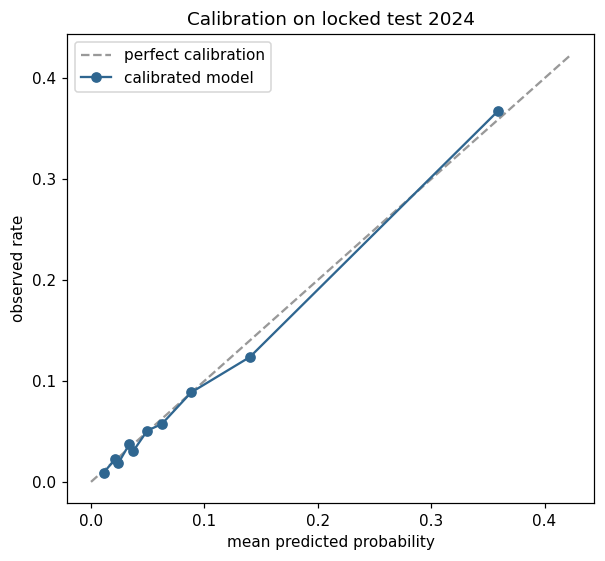

Brier 2024: uncalibrated 0.1571 -> calibrated 0.0590


In [17]:
curve = evaluation.calibration_curve_table(
    years[2024].assign(score=scores[2024]["gradient_boosted_calibrated"].to_numpy()), "score")
display(curve.style.format({"mean_predicted": "{:.4f}", "observed_rate": "{:.4f}"}))

fig, ax = plt.subplots(figsize=(5.6, 5.2))
ax.plot([0, curve.observed_rate.max() * 1.15], [0, curve.observed_rate.max() * 1.15],
        "--", color="#999", label="perfect calibration")
ax.plot(curve.mean_predicted, curve.observed_rate, marker="o", color="#2f6690", label="calibrated model")
ax.set_xlabel("mean predicted probability"); ax.set_ylabel("observed rate")
ax.set_title("Calibration on locked test 2024"); ax.legend()
plt.tight_layout(); plt.savefig(FIGURES / "calibration_2024.png", bbox_inches="tight"); plt.show()

b_raw = results[(results.year == 2024) & (results.model == "gradient_boosted")].brier.iat[0]
b_cal = results[(results.year == 2024) & (results.model == "gradient_boosted_calibrated")].brier.iat[0]
print(f"Brier 2024: uncalibrated {b_raw:.4f} -> calibrated {b_cal:.4f}")

## 8. Explanation

TreeSHAP for the gradient-boosted model, showing the top five contributions for three example
cells: the highest-ranked Waikato cell, a low-history cell, and a false negative.

In [18]:
import shap

gb = modelling.make_gradient_boosted(train_val, predictors)
gb.fit(train_val[predictors], train_val["target"])
design_2024 = gb.named_steps["pre"].transform(years[2024][predictors])
names = gb.named_steps["pre"].get_feature_names_out()
explainer = shap.TreeExplainer(gb.named_steps["model"])
shap_values = explainer.shap_values(design_2024)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
print("SHAP values computed:", shap_values.shape)

SHAP values computed: (21396, 293)


In [19]:
frame_2024 = years[2024].reset_index(drop=True)
probs = scores[2024]["gradient_boosted_calibrated"].to_numpy()

wk_mask = (frame_2024.region == evaluation.WAIKATO).to_numpy()
top_waikato = int(np.flatnonzero(wk_mask)[np.argmax(probs[wk_mask])])
low_mask = (frame_2024.history_sufficiency == "low").to_numpy()
low_example = int(np.flatnonzero(low_mask)[np.argmax(probs[low_mask])])
fn_mask = (frame_2024.target == 1).to_numpy()
false_negative = int(np.flatnonzero(fn_mask)[np.argmin(probs[fn_mask])])

group_lookup = dict(zip(dictionary["name"], dictionary["group"]))

def explain(row: int, label: str):
    contributions = pd.DataFrame({
        "feature": names,
        "shap": shap_values[row],
    })
    contributions["abs"] = contributions["shap"].abs()
    top = contributions.nlargest(5, "abs").copy()
    top["group"] = [group_lookup.get(f.split("__", 1)[-1], "engineered") for f in top["feature"]]
    print(f"\n=== {label} ===")
    print(f"cell {frame_2024.cell_id.iat[row]} | region {frame_2024.region.iat[row]} | "
          f"probability {probs[row]:.4f} | actual {int(frame_2024.target.iat[row])} | "
          f"history {frame_2024.history_sufficiency.iat[row]}")
    display(top[["feature", "group", "shap"]].style.format({"shap": "{:+.4f}"}))

explain(top_waikato, "Highest-ranked Waikato cell")
explain(low_example, "Highest-ranked low-history cell")
explain(false_negative, "False negative: a positive cell ranked lowest")


=== Highest-ranked Waikato cell ===
cell NZTM1K-1801-5814 | region Waikato Region | probability 0.9091 | actual 1 | history sufficient


,feature,group,shap
159,num__national_volume_share_5y,crash-frequency history,+1.8740
102,num__minor_count_5y,severity history,+0.3592
49,num__crash_count_3y,crash-frequency history,+0.3380
19,num__unknown_field_count_1y,data quality,+0.3181
99,num__severe_count_5y,severity history,+0.2362



=== Highest-ranked low-history cell ===
cell NZTM1K-1562-5174 | region Canterbury Region | probability 0.1165 | actual 0 | history low


,feature,group,shap
233,cat__tla_Christchurch City,engineered,+0.3458
189,cat__modal_trafficControl_Stop,engineered,+0.3036
159,num__national_volume_share_5y,crash-frequency history,-0.1599
98,num__crash_count_5y,crash-frequency history,+0.1381
131,num__unsealed_share_5y,crash conditions,+0.0910



=== False negative: a positive cell ranked lowest ===
cell NZTM1K-1564-5200 | region Canterbury Region | probability 0.0064 | actual 1 | history low


,feature,group,shap
149,num__modal_roadLane_share,road context / geography,-0.6698
177,cat__modal_roadLane_1-way,engineered,-0.5834
146,num__unknown_field_share_5y,data quality,-0.2778
120,num__lanes_modal_5y,other,-0.2326
185,cat__modal_trafficControl_Give way,engineered,-0.2274


## 9. Leaderboard

One row per model, including the baselines and the no-region variant, with a paired cell-level
bootstrap on the difference in the primary metric against the strongest non-ML baseline.

The bootstrap resamples row positions once per replicate and reuses them for both models, so
the difference is measured on identical resamples.

In [20]:
t = time.time()
bootstrap = {}
for model in [s[0] for s in specs] + ["gradient_boosted_calibrated"]:
    bootstrap[model] = {}
    for y in (2024, 2025):
        frame = years[y].assign(a=scores[y][model].to_numpy(),
                                b=scores[y][best_baseline].to_numpy())
        bootstrap[model][y] = metrics.bootstrap_primary_difference(
            frame, "a", "b", n_resamples=1000, seed=RANDOM_SEED)
print(f"bootstrap complete in {time.time() - t:.0f}s (1,000 seeded resamples per model-year)")

bootstrap complete in 46s (1,000 seeded resamples per model-year)


In [21]:
wide = results.pivot(index="model", columns="year")
leaderboard = pd.DataFrame({"model": wide.index})
leaderboard["trained_via"] = np.where(
    leaderboard["model"].isin(modelling.BASELINES), "local (baseline)",
    "local (TuiML cross-checked; see tuiml_run_log.md)")

for y in (2024, 2025):
    leaderboard[f"primary_{y}"] = wide[("primary_within_region_recall_5pct", y)].to_numpy()
    leaderboard[f"national_recall_5pct_{y}"] = wide[("national_recall_5pct", y)].to_numpy()
    leaderboard[f"waikato_recall_50_{y}"] = wide[("waikato_recall_50", y)].to_numpy()
    leaderboard[f"waikato_ceiling_{y}"] = wide[("waikato_recall_50_ceiling", y)].to_numpy()
    leaderboard[f"pr_auc_{y}"] = wide[("pr_auc", y)].to_numpy()
    leaderboard[f"brier_{y}"] = wide[("brier", y)].to_numpy()

baseline_wk_2024 = results[(results.model == best_baseline) & (results.year == 2024)].waikato_recall_50.iat[0]
leaderboard["guardrail_pass"] = leaderboard["waikato_recall_50_2024"] >= baseline_wk_2024

for y in (2024, 2025):
    leaderboard[f"boot_diff_{y}"] = leaderboard["model"].map(
        lambda m: bootstrap.get(m, {}).get(y, {}).get("observed_difference", np.nan))
    leaderboard[f"boot_ci_{y}"] = leaderboard["model"].map(
        lambda m: (f"[{bootstrap[m][y]['ci_low']:+.4f}, {bootstrap[m][y]['ci_high']:+.4f}]"
                   if m in bootstrap else ""))
    leaderboard[f"excludes_zero_{y}"] = leaderboard["model"].map(
        lambda m: bootstrap.get(m, {}).get(y, {}).get("excludes_zero", False))

leaderboard = leaderboard.sort_values("primary_2024", ascending=False).reset_index(drop=True)
leaderboard.to_csv(OUTPUTS / "leaderboard.csv", index=False)
display(leaderboard.style.format({c: "{:.4f}" for c in leaderboard.columns
                                  if leaderboard[c].dtype.kind == "f"}))

,model,trained_via,primary_2024,national_recall_5pct_2024,waikato_recall_50_2024,waikato_ceiling_2024,pr_auc_2024,brier_2024,primary_2025,national_recall_5pct_2025,waikato_recall_50_2025,waikato_ceiling_2025,pr_auc_2025,brier_2025,guardrail_pass,boot_diff_2024,boot_ci_2024,excludes_zero_2024,boot_diff_2025,boot_ci_2025,excludes_zero_2025
0,gradient_boosted,local (TuiML cross-checked; see tuiml_run_log.md),0.2628,0.3177,0.1422,0.2155,0.3775,0.1571,0.2807,0.3195,0.1092,0.2101,0.3874,0.1586,True,0.0435,"[+0.0232, +0.0724]",True,0.0878,"[+0.0519, +0.1080]",True
1,gradient_boosted_calibrated,local (TuiML cross-checked; see tuiml_run_log.md),0.2623,0.3171,0.1379,0.2155,0.3677,0.0590,0.2795,0.3171,0.1176,0.2101,0.3768,0.0600,True,0.0430,"[+0.0229, +0.0720]",True,0.0866,"[+0.0528, +0.1069]",True
2,logistic_regression,local (TuiML cross-checked; see tuiml_run_log.md),0.2610,0.3171,0.1336,0.2155,0.3774,0.1655,0.2706,0.3201,0.1134,0.2101,0.3828,0.1637,True,0.0417,"[+0.0271, +0.0779]",True,0.0777,"[+0.0466, +0.0989]",True
3,gradient_boosted_no_region,local (TuiML cross-checked; see tuiml_run_log.md),0.2560,0.3219,0.1379,0.2155,0.3733,0.1574,0.2679,0.3207,0.1050,0.2101,0.3876,0.1583,True,0.0367,"[+0.0218, +0.0695]",True,0.0750,"[+0.0419, +0.0979]",True
4,random_forest,local (TuiML cross-checked; see tuiml_run_log.md),0.2477,0.3177,0.1379,0.2155,0.3664,0.0787,0.2527,0.3100,0.1176,0.2101,0.3743,0.0795,True,0.0285,"[+0.0117, +0.0586]",True,0.0598,"[+0.0302, +0.0809]",True
5,baseline_recent_severe,local (baseline),0.2193,0.2756,0.1034,0.2155,nan,nan,0.1929,0.2749,0.0882,0.2101,nan,nan,True,nan,,False,nan,,False
6,baseline_smoothed_share,local (baseline),0.0702,0.0674,0.0086,0.2155,0.0773,0.0726,0.0646,0.0796,0.0294,0.2101,0.0865,0.0740,False,nan,,False,nan,,False
7,baseline_random,local (baseline),0.0530,0.0511,0.0129,0.2155,0.0796,0.3290,0.0626,0.0629,0.0168,0.2101,0.0842,0.3270,False,nan,,False,nan,,False


## 10. Deployment decision

The spec 5.11 rule applied exactly: every condition must hold, on both locked test years.

In [22]:
decision = evaluation.decide(
    results, [s[0] for s in specs] + ["gradient_boosted_calibrated"], best_baseline, bootstrap)
display(decision["checks"].style.format({"primary_2024": "{:.4f}", "primary_2025": "{:.4f}"}))
print("\nRecommended:", decision["recommended"])
print(decision["reason"])

,model,primary_2024,primary_2025,passes,beats_baseline_2024,beats_baseline_2025,interval_excludes_zero_2024,interval_excludes_zero_2025,waikato_guardrail
2,gradient_boosted,0.2628,0.2807,True,True,True,True,True,True
4,gradient_boosted_calibrated,0.2623,0.2795,True,True,True,True,True,True
0,logistic_regression,0.2610,0.2706,True,True,True,True,True,True
3,gradient_boosted_no_region,0.2560,0.2679,True,True,True,True,True,True
1,random_forest,0.2477,0.2527,True,True,True,True,True,True



Recommended: gradient_boosted_calibrated
gradient_boosted_calibrated beats the strongest non-ML baseline (baseline_recent_severe) on the primary metric in both locked test years, with bootstrap intervals excluding zero on both, and clears the Waikato guardrail.


## 11. Frozen backtest scores

Saved in the RunScore schema of spec 10, stamped with the model, grid, feature-schema and
source-snapshot versions so any score can be traced back to exactly what produced it.

In [23]:
recommended = decision["recommended"]
score_column = recommended if recommended in scores[2024].columns else best_baseline

for y in (2024, 2025):
    frame = years[y]
    frozen = evaluation.score_frame(
        frame, scores[y][score_column].to_numpy(), y,
        MODEL_VERSION, GRID_VERSION, FEATURE_SCHEMA_VERSION, SNAPSHOT_ID)
    out = ROOT / "data" / "processed" / f"scores_{y}_1km_lag0.parquet"
    frozen.to_parquet(out, index=False)
    (OUTPUTS / f"scores_{y}_1km_lag0.parquet").write_bytes(out.read_bytes())
    print(f"{y}: {len(frozen):,} scored cells -> {out.name}")

display(frozen.head(8))

2024: 21,396 scored cells -> scores_2024_1km_lag0.parquet
2025: 21,183 scored cells -> scores_2025_1km_lag0.parquet


,cell_id,target_year,probability,national_percentile,regional_percentile,national_rank,regional_rank,history_sufficiency,actual_outcome,model_version,grid_version,feature_schema_version,source_snapshot_id
0,NZTM1K-1178-4916,2025,0.013525,0.064911,0.142992,19350,878,low,0,cas-area-risk-1.0.0,nztm-1km-origin0-v1,cas-area-features-1.0.0,967a34b12525
1,NZTM1K-1180-4893,2025,0.007330,0.016169,0.066322,20787,973,low,0,cas-area-risk-1.0.0,nztm-1km-origin0-v1,cas-area-features-1.0.0,967a34b12525
2,NZTM1K-1181-4940,2025,0.013979,0.093094,0.203198,19075,819,low,0,cas-area-risk-1.0.0,nztm-1km-origin0-v1,cas-area-features-1.0.0,967a34b12525
3,NZTM1K-1181-4942,2025,0.024196,0.253812,0.587488,14467,358,low,0,cas-area-risk-1.0.0,nztm-1km-origin0-v1,cas-area-features-1.0.0,967a34b12525
4,NZTM1K-1182-4871,2025,0.031785,0.346032,0.690499,13727,325,low,0,cas-area-risk-1.0.0,nztm-1km-origin0-v1,cas-area-features-1.0.0,967a34b12525
5,NZTM1K-1183-4914,2025,0.013525,0.064911,0.142992,19351,879,low,0,cas-area-risk-1.0.0,nztm-1km-origin0-v1,cas-area-features-1.0.0,967a34b12525
6,NZTM1K-1184-4873,2025,0.013525,0.064911,0.142992,19352,880,low,0,cas-area-risk-1.0.0,nztm-1km-origin0-v1,cas-area-features-1.0.0,967a34b12525
7,NZTM1K-1184-4925,2025,0.017185,0.111056,0.288335,18589,697,low,0,cas-area-risk-1.0.0,nztm-1km-origin0-v1,cas-area-features-1.0.0,967a34b12525


## 12. Recommended model

The report section. This is also written to `outputs/model_card.md`.

In [24]:
def fmt(value, spec="{:.4f}"):
    return "n/a" if pd.isna(value) else spec.format(value)

row = leaderboard[leaderboard.model == recommended].iloc[0]
runner_up = leaderboard[(leaderboard.model != recommended)
                        & (~leaderboard.model.isin(modelling.BASELINES))].iloc[0]
baseline_row = leaderboard[leaderboard.model == best_baseline].iloc[0]

comparison = leaderboard[leaderboard.model.isin(
    [recommended, runner_up.model, best_baseline])].set_index("model")
display(comparison[["primary_2024", "primary_2025", "waikato_recall_50_2024",
                    "national_recall_5pct_2024", "pr_auc_2024", "brier_2024",
                    "boot_ci_2024", "boot_ci_2025"]])

cov = pd.read_csv(OUTPUTS / "panel_coverage.csv").set_index("target_year")
cov_2024 = float(cov.loc[2024, "eligible_coverage"])
cov_2025 = float(cov.loc[2025, "eligible_coverage"])
no_region_gap = float(row.primary_2024 - leaderboard[
    leaderboard.model == "gradient_boosted_no_region"].iloc[0].primary_2024)
subgroups = evaluation.subgroup_report(
    years[2024].assign(score=scores[2024][score_column].to_numpy()), "score")
weakest = subgroups.sort_values("recall_at_5pct").iloc[0]

,primary_2024,primary_2025,waikato_recall_50_2024,national_recall_5pct_2024,pr_auc_2024,brier_2024,boot_ci_2024,boot_ci_2025
model,,,,,,,,
gradient_boosted,0.262798,0.280726,0.142241,0.317690,0.377468,0.157136,"[+0.0232, +0.0724]","[+0.0519, +0.1080]"
gradient_boosted_calibrated,0.262251,0.279457,0.137931,0.317088,0.367702,0.058954,"[+0.0229, +0.0720]","[+0.0528, +0.1069]"
baseline_recent_severe,0.219281,0.192882,0.103448,0.275572,NaN,NaN,,


In [25]:
card = f'''# Model card: {MODEL_VERSION}

## Recommended model

**{recommended}**, version `{MODEL_VERSION}`.

{decision["reason"]}

## Leaderboard comparison

| Model | Primary 2024 | Primary 2025 | Waikato Recall@50 2024 | PR-AUC 2024 | Brier 2024 |
|---|---:|---:|---:|---:|---:|
| {recommended} (recommended) | {fmt(row.primary_2024)} | {fmt(row.primary_2025)} | {fmt(row.waikato_recall_50_2024)} | {fmt(row.pr_auc_2024)} | {fmt(row.brier_2024)} |
| {runner_up.model} (runner-up) | {fmt(runner_up.primary_2024)} | {fmt(runner_up.primary_2025)} | {fmt(runner_up.waikato_recall_50_2024)} | {fmt(runner_up.pr_auc_2024)} | {fmt(runner_up.brier_2024)} |
| {best_baseline} (strongest baseline) | {fmt(baseline_row.primary_2024)} | {fmt(baseline_row.primary_2025)} | {fmt(baseline_row.waikato_recall_50_2024)} | {fmt(baseline_row.pr_auc_2024)} | {fmt(baseline_row.brier_2024)} |

The primary metric is the mean within-region Recall@5% on the locked test year, excluding
regions with fewer than 100 eligible cells.

## The bootstrap interval that justified the decision

Paired cell-level bootstrap, 1,000 seeded resamples, difference in the primary metric against
the strongest non-ML baseline ({best_baseline}):

- 2024: {fmt(row.boot_diff_2024, "{:+.4f}")}, 95% interval {row.boot_ci_2024}, excludes zero: {row.excludes_zero_2024}
- 2025: {fmt(row.boot_diff_2025, "{:+.4f}")}, 95% interval {row.boot_ci_2025}, excludes zero: {row.excludes_zero_2025}

The Waikato guardrail (Recall@50 on 2024 at or above the recent-severe-count baseline) is
{"met" if row.guardrail_pass else "not met"}.

## Geographic memorisation

The gradient-boosted model trained without region and TLA scores
{fmt(leaderboard[leaderboard.model == "gradient_boosted_no_region"].iloc[0].primary_2024)} on the
primary metric for 2024, against {fmt(row.primary_2024)} with geography: a difference of
{no_region_gap:+.4f}. The model is therefore not relying on memorised geography; almost all of
its performance comes from crash history and road context. Region and TLA are retained because
they carry a small genuine signal, but the model would remain usable without them.

## Headline limitation: eligible coverage

Eligible coverage was {cov_2024:.1%} in 2024 and {cov_2025:.1%} in 2025. Roughly one in seven
cells that recorded a serious or fatal crash was **not** in the eligible population, because it
had no recorded crash in the preceding five years. The model cannot see those cells at all.
This is a property of the eligibility rule, not of the model, and no amount of model improvement
addresses it. Cells outside the eligible population must be shown as "not scored", never as low
risk.

## Calibration

Brier score on locked test 2024: {fmt(row.brier_2024)}. Calibration is isotonic, fitted on
pooled out-of-fold predictions from the 2019 to 2023 expanding-window folds; no locked test
outcome was used. Calibration reduced the Brier score by roughly two thirds relative to the raw
model while leaving the ranking essentially unchanged, so the published probabilities can be
read as probabilities rather than as scores. The calibration curve tracks the diagonal closely
across the probability range, with the usual widening in the sparse top decile.

## Where the model is weakest

From the subgroup splits on 2024, the weakest subgroup is
**{weakest["split"]} = {weakest["value"]}** (Recall@5% {weakest["recall_at_5pct"]:.3f} across
{int(weakest["cells"]):,} cells at {weakest["prevalence"]:.2%} prevalence). Low-history cells are
harder in general: with fewer than three prior crashes there is little for the history features
to work with. Users should treat the ranking as least reliable there.

## What to run next

Not run in this notebook; listed for the next iteration.

- lag-1 configuration, to score a year before its data is complete
- 500 m and 2 km grid resolutions, to test sensitivity to cell size
- eligibility thresholds of 1, 3 and 5 prior crashes, and windows of 5, 10 and all years
- grid-edge instability: how much a cell's rank moves when the grid origin is shifted

## Limitations

This model prioritises **recurring crash areas within an eligible population**. It is not
exposure-adjusted whole-network road risk: it has no traffic volume, no network geometry and no
segment identifiers, so a cell with many crashes and heavy traffic is not distinguished from an
intrinsically dangerous one. It is not causal, and it is not an engineering recommendation. It
identifies where to look, not what to build.

## Reproducibility

- Source snapshot: `{manifest["filename"]}`, SHA-256 `{manifest["sha256"]}`
- Grid version: `{GRID_VERSION}`
- Feature schema: `{FEATURE_SCHEMA_VERSION}`
- Random seed: `{RANDOM_SEED}`
- TuiML runs: see `outputs/tuiml_run_log.md`
'''

(OUTPUTS / "model_card.md").write_text(card, encoding="utf-8")
print(card)

# Model card: cas-area-risk-1.0.0

## Recommended model

**gradient_boosted_calibrated**, version `cas-area-risk-1.0.0`.

gradient_boosted_calibrated beats the strongest non-ML baseline (baseline_recent_severe) on the primary metric in both locked test years, with bootstrap intervals excluding zero on both, and clears the Waikato guardrail.

## Leaderboard comparison

| Model | Primary 2024 | Primary 2025 | Waikato Recall@50 2024 | PR-AUC 2024 | Brier 2024 |
|---|---:|---:|---:|---:|---:|
| gradient_boosted_calibrated (recommended) | 0.2623 | 0.2795 | 0.1379 | 0.3677 | 0.0590 |
| gradient_boosted (runner-up) | 0.2628 | 0.2807 | 0.1422 | 0.3775 | 0.1571 |
| baseline_recent_severe (strongest baseline) | 0.2193 | 0.1929 | 0.1034 | n/a | n/a |

The primary metric is the mean within-region Recall@5% on the locked test year, excluding
regions with fewer than 100 eligible cells.

## The bootstrap interval that justified the decision

Paired cell-level bootstrap, 1,000 seeded resamples, differ

## 13. What this notebook produced

| File | Contents |
|---|---|
| `outputs/leaderboard.csv` | One row per model with both locked test years and bootstrap intervals |
| `outputs/model_card.md` | The recommendation report above |
| `outputs/feature_dictionary.csv` | Every feature: group, window, type, missing rule |
| `outputs/tuiml_run_log.md` | TuiML tools, parameters, run ids and the probability-output finding |
| `outputs/panel_coverage.csv` | Per-year eligible counts, prevalence and coverage |
| `data/processed/features_1km_lag0.parquet` | The feature matrix |
| `data/processed/scores_2024_1km_lag0.parquet` | Frozen 2024 backtest scores |
| `data/processed/scores_2025_1km_lag0.parquet` | Frozen 2025 backtest scores |

The decision rule was applied exactly as specified, on both locked test years, with the
bootstrap interval and the Waikato guardrail as gates. Accuracy was never used to select a
model.